In [1]:
from copy import deepcopy
from time import time

import numpy as np

import galsim

import ngmix
import metadetect

from roman_shear_sims.sim import make_sim
from roman_shear_sims.catalog import GalaxyCatalog, SimpleGalaxyCatalog
from roman_shear_sims.psf_makers import PSFMaker
from roman_shear_sims.constant import IMCOM_BLOCK_SIZE

from metacoadd.metadetect import MetaDetect
from metacoadd.moments.galsim_admom import GAdmomFitter

In [2]:
import matplotlib.pyplot as plt

In [3]:
seed = 4242
rng = np.random.RandomState(seed)

simu_type = "imcom"
simu_size = IMCOM_BLOCK_SIZE
bands = ["Y106", "J129", "H158"]
gal_type = "gauss"
psf_type = simu_type
layout_kind = "grid"
chromatic=False
spacing = 12.
buff = 200
noise_sig = 1e-5
n_gal = None
gal_mag = 22
gal_hlr = 0.3
flux_range = [100, 1_00]

g1_in = 0.02
g2_in = 0.02

n_epochs = 1

exp_time=107

### Set Galaxy Catalog

In [4]:
# galaxy_catalog = GalaxyCatalog(
#     simu_size,
#     seed,
#     simu_type=simu_type,
#     flux_range=flux_range,
#     layout_kind=layout_kind,
#     exp_time=exp_time,
#     spacing=spacing,
#     buffer=buff,
#     n_gal=n_gal,
#     chromatic=chromatic,
# )
galaxy_catalog = SimpleGalaxyCatalog(
    simu_size,
    seed,
    simu_type=simu_type,
    gal_type=gal_type,
    mag=gal_mag,
    hlr=gal_hlr,
    layout_kind=layout_kind,
    exp_time=exp_time,
    spacing=spacing,
    buffer=buff,
    n_gal=n_gal,
    chromatic=chromatic,
)

### Set the PSF

In [5]:
psf_maker = PSFMaker(
    psf_type=psf_type,
    chromatic=chromatic,
)

### Run the simulation

In [6]:
simu_dict = make_sim(
    rng,
    galaxy_catalog,
    psf_maker,
    simu_type=simu_type,
    n_epochs=n_epochs,
    exp_time=exp_time,
    cell_size_pix=simu_size,
    bands=bands,
    g1=g1_in,
    g2=g2_in,
    chromatic=chromatic,
    simple_noise=True,
    noise_sigma=noise_sig,
    draw_method="fft",
    verbose=True,
)

Band loop:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch loop:   0%|          | 0/1 [00:00<?, ?it/s]

Obj loop:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch loop:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

Text(0.5, 1.0, 'Gaussian profiles')

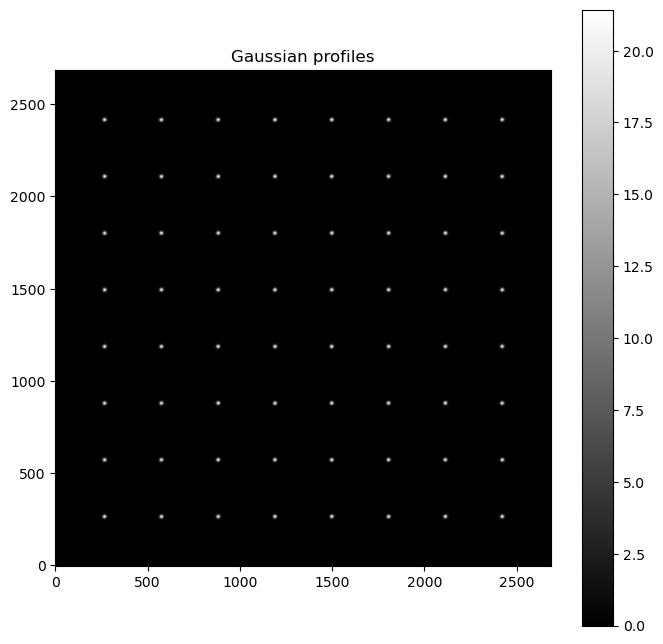

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(simu_dict["Y106"][0]["sci"][f"shear_{g1_in}_{g2_in}"], origin="lower", cmap="gray")
plt.colorbar()
plt.title("Gaussian profiles")

### Run MetaDetect

In [ ]:
# Make Observation
mbobs = ngmix.MultiBandObsList()
for band in bands:
    obslist = ngmix.ObsList()
    for i in range(n_epochs):
        print(f"Processing band {band}, epoch {i}")

        wcs = simu_dict[band][i]["wcs"]
        h = wcs.header
        g_jacob = wcs.jacobian(image_pos=galsim.PositionD(h["CRPIX1"], h["CRPIX2"]))

        img = simu_dict[band][i]["sci"][f"shear_{g1_in}_{g2_in}"]
        img_cen = (np.array(img.shape) - 1) / 2.0
        img_jacob = ngmix.Jacobian(
            row=img_cen[1],
            col=img_cen[0],
            wcs=g_jacob,
        )

        psf_img = simu_dict[band][i]["psf"]
        psf_cen = (np.array(psf_img.shape) - 1) / 2.0
        psf_jacob = ngmix.Jacobian(
            row=psf_cen[1],
            col=psf_cen[0],
            wcs=g_jacob,
        )

        psf_obs = ngmix.Observation(
            image=psf_img,
            jacobian=psf_jacob,
        )

        obs = ngmix.Observation(
            image=img,
            weight=simu_dict["Y106"][0]["weight"],
            noise=simu_dict[band][i]["noise"],
            psf=psf_obs,
            jacobian=img_jacob,
            ormask=np.zeros(img.shape, dtype=np.int32),
            bmask=np.zeros(img.shape, dtype=np.int32),
        )

        obslist.append(obs)
    mbobs.append(obslist)


Processing band Y106, epoch 0
Processing band J129, epoch 0
Processing band H158, epoch 0


In [ ]:
mbobs

[[<ngmix.observation.Observation at 0x37dc49ac0>],

In [ ]:
gal_fitter = ngmix.gaussmom.GaussMom(fwhm=1.2)
gal_runner = ngmix.runners.Runner(fitter=gal_fitter)

psf_fitter = GAdmomFitter(guess_fwhm=0.6)
psf_runner = ngmix.runners.Runner(fitter=psf_fitter)


rng = np.random.RandomState(42)
mdet = MetaDetect(
    mbobs,
    rng=rng,
    psf_runner=psf_runner,
    gal_runners={"wmom": gal_runner},
    mcal_config={
        "fixnoise": True,
        "has_pixel": True,
    }
)

In [ ]:
ts = time()
mdet._init_metacal()
mcal_mbobs = mdet.get_mcal("noshear")  # Just for timing comparison
mcal_mbobs = mdet.get_mcal("1p")
print(f"Time to get mcal mbobs: {time() - ts:.2f} seconds")

In [ ]:
ts = time()
mcal_mbobs2 = ngmix.metacal.get_all_metacal(
    mbobs,
    psf="fitgauss",
    rng=np.random.RandomState(42),
    types=["noshear", "1p"],#, "1m", "2p", "2m"],
    use_noise_image=True,
    fixnoise=True,
)
print(f"Time to get mcal mbobs with ngmix: {time() - ts:.2f} seconds")

Text(0.5, 1.0, 'Reconv PSF\nMetacoadd - ngmix.metacal')

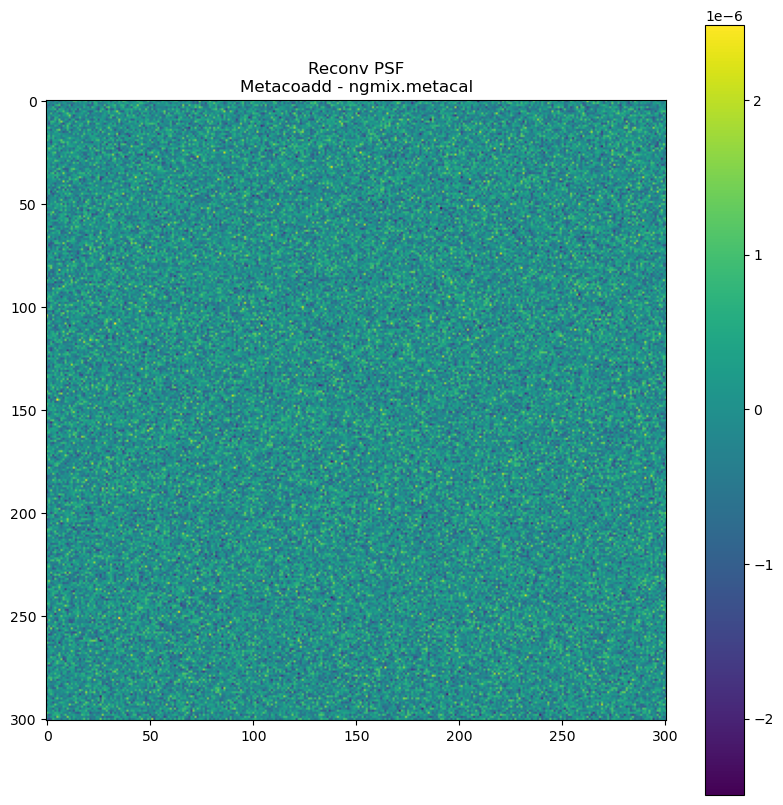

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(mcal_mbobs[0][0].psf.image-mcal_mbobs2["1p"][0][0].psf.image)
plt.colorbar()
plt.title("Reconv PSF\nMetacoadd - ngmix.metacal")

Text(0.5, 1.0, '1p image\nMetacoadd - ngmix.metacal')

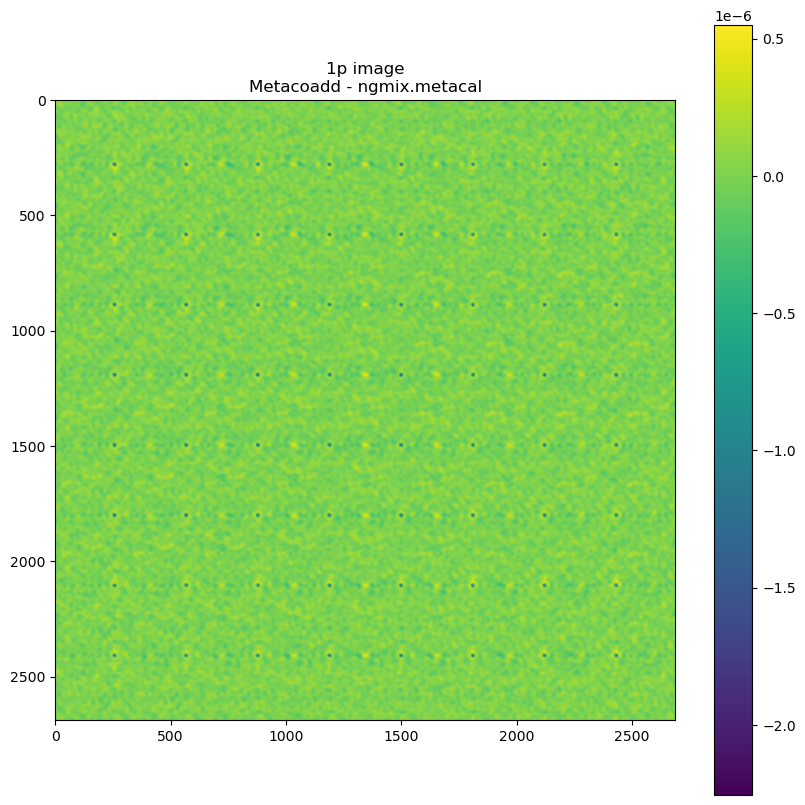

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(mcal_mbobs[0][0].image-mcal_mbobs2["1p"][0][0].image)
plt.colorbar()
plt.title("1p image\nMetacoadd - ngmix.metacal")

Text(0.5, 1.0, '1p image\nMetacoadd - ngmix.metacal')

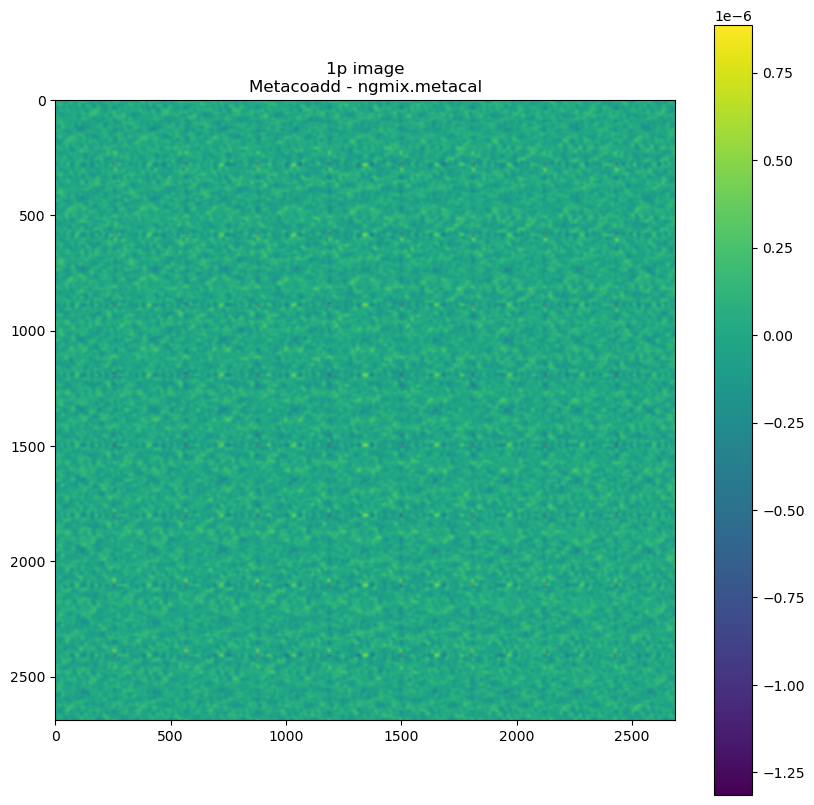

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(mcal_mbobs[2][0].image-mcal_mbobs2["1p"][2][0].image)
plt.colorbar()
plt.title("1p image\nMetacoadd - ngmix.metacal")

In [ ]:
ts = time()
rng = np.random.RandomState(42)
mdet = MetaDetect(
    mbobs,
    rng=rng,
    psf_runner=psf_runner,
    gal_runners={"wmom": gal_runner},
)
final_cat = mdet.go()
print(f"Time to run MetaDetect: {time() - ts:.2f} seconds")

In [ ]:
final_cat["1p"]["wmom_g1"]

array([0.04086752, 0.04087036, 0.04087322, 0.0408821 , 0.04087634,
       0.04087944, 0.04088509, 0.04088798, 0.04087915, 0.04086751,
       0.04087067, 0.04087296, 0.04087628, 0.04088192, 0.0408854 ,
       0.04088843, 0.04086726, 0.04087017, 0.04087338, 0.04087602,
       0.04087917, 0.04088196, 0.04088502, 0.04088807, 0.04086717,
       0.04087025, 0.04087309, 0.04087633, 0.04087914, 0.04088223,
       0.04088512, 0.04088819, 0.0408671 , 0.04086999, 0.04087301,
       0.04087614, 0.04087928, 0.04088227, 0.04088808, 0.04088525,
       0.04086725, 0.04087617, 0.04088827, 0.04087011, 0.04087297,
       0.04087904, 0.0408819 , 0.04088527, 0.04087041, 0.0408732 ,
       0.04088845, 0.04086726, 0.04087628, 0.04087921, 0.04088191,
       0.04088532, 0.04087049, 0.04086728, 0.04087324, 0.04087611,
       0.04087919, 0.04088222, 0.04088537, 0.04088835])

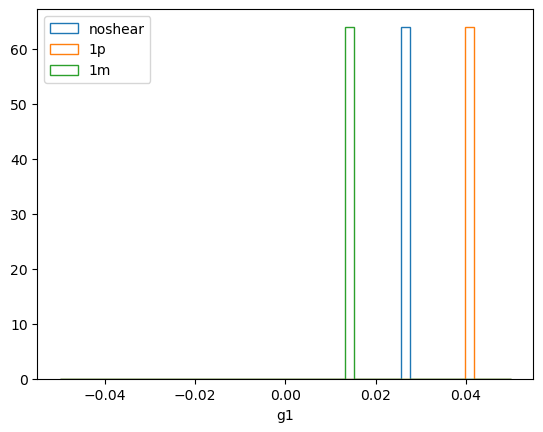

In [ ]:
bins = np.linspace(-0.05, 0.05, 50)
plt.hist(final_cat["noshear"]["wmom_g1"], bins, histtype="step", label="noshear")
plt.hist(final_cat["1p"]["wmom_g1"], bins, histtype="step", label="1p")
plt.hist(final_cat["1m"]["wmom_g1"], bins, histtype="step", label="1m")
plt.xlabel("g1")
plt.legend()

### Run "offcial" MetaDetect

In [ ]:
# Size of the taget Gaussian PSF in IMCOM
PSF_FWHM = {
    "Y106": 0.22,
    "J129": 0.231,
    "H158": 0.242,
    "F184": 0.253,
    "K213": 0.264,
}
# Size of the image used to draw the PSF
PSF_IMG_SIZE = 151

# Size of one IMCOM block
IMG_SIZE = 2688
# Boundary used to avoid edge effects
# Objects for which the centre is within this distance from the edge will be
# masked out.
BOUND_SIZE = 100

METADETECT_CONFIG = {
    # Shape measurement method
    # wmom: weighted moments
    "model": "wmom",
    # "model": "gauss",

    # Size of the weight function for the moments
    'weight': {
        'fwhm': 1.2,  # arcsec
    },

    # Metacal settings
    'metacal': {
        'psf': 'fitgauss',
        # Kind of shear applied to the image
        'types': ['noshear', '1p', '1m', '2p', '2m'],
        'use_noise_image': True,
        'fixnoise': True,
    },

    'sx': {
        # in sky sigma
        # DETECT_THRESH
        'detect_thresh': 1500,

        # Minimum contrast parameter for deblending
        # DEBLEND_MINCONT
        'deblend_cont': 0.005,

        # minimum number of pixels above threshold
        # DETECT_MINAREA: 6
        'minarea': 5,

        'filter_type': 'conv',

        # 7x7 convolution mask of a gaussian PSF with FWHM = 3.0 pixels.
        'filter_kernel': [
            [0.004963, 0.021388, 0.051328, 0.068707, 0.051328, 0.021388, 0.004963],  # noqa
            [0.021388, 0.092163, 0.221178, 0.296069, 0.221178, 0.092163, 0.021388],  # noqa
            [0.051328, 0.221178, 0.530797, 0.710525, 0.530797, 0.221178, 0.051328],  # noqa
            [0.068707, 0.296069, 0.710525, 0.951108, 0.710525, 0.296069, 0.068707],  # noqa
            [0.051328, 0.221178, 0.530797, 0.710525, 0.530797, 0.221178, 0.051328],  # noqa
            [0.021388, 0.092163, 0.221178, 0.296069, 0.221178, 0.092163, 0.021388],  # noqa
            [0.004963, 0.021388, 0.051328, 0.068707, 0.051328, 0.021388, 0.004963],  # noqa
        ]
    },

    # This is for the cutout at each detection
    'meds': {
        'min_box_size': 101,
        'max_box_size': 101,

        'box_type': 'iso_radius',

        'rad_min': 4,
        'rad_fac': 2,
        'box_padding': 2,
    },

    # check for an edge hit
    'bmask_flags': 2**30,

    'nodet_flags': 2**0,
}

In [ ]:
ts = time()
res = metadetect.do_metadetect(
    deepcopy(METADETECT_CONFIG),
    mbobs=mbobs,
    rng=np.random.RandomState(42),
)
print(f'Time to run metadetect "offcial": {time() - ts:.2f} seconds')

In [ ]:
res["1p"]["wmom_g"][:, 0]

array([0.04086748, 0.04087034, 0.04087315, 0.04088215, 0.04087635,
       0.04087939, 0.04088522, 0.04088831, 0.0408792 , 0.04086733,
       0.04087031, 0.04087316, 0.04087623, 0.04088203, 0.04088527,
       0.04088838, 0.04086719, 0.04087021, 0.04087328, 0.04087622,
       0.0408792 , 0.04088206, 0.04088511, 0.0408881 , 0.04086713,
       0.04087021, 0.04087317, 0.04087617, 0.0408791 , 0.04088209,
       0.04088505, 0.0408882 , 0.04086714, 0.0408702 , 0.04087308,
       0.04087624, 0.04087911, 0.04088224, 0.04088807, 0.04088519,
       0.04086729, 0.04087608, 0.04088822, 0.04087014, 0.04087315,
       0.04087915, 0.04088218, 0.04088523, 0.04087031, 0.04087318,
       0.04088829, 0.04086728, 0.04087625, 0.04087925, 0.04088208,
       0.04088526, 0.04087039, 0.04086735, 0.0408734 , 0.04087615,
       0.04087934, 0.04088219, 0.04088538, 0.04088846])

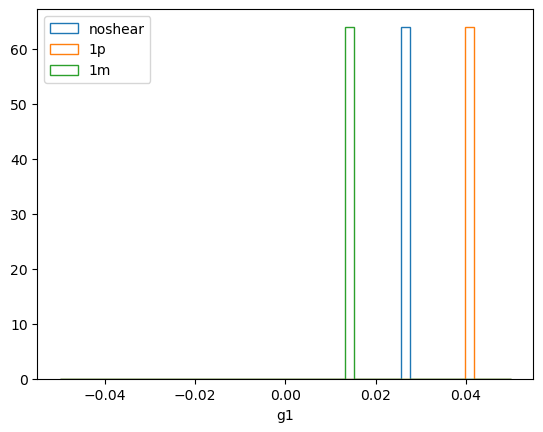

In [ ]:
bins = np.linspace(-0.05, 0.05, 50)
plt.hist(res["noshear"]["wmom_g"][:, 0], bins, histtype="step", label="noshear")
plt.hist(res["1p"]["wmom_g"][:, 0], bins, histtype="step", label="1p")
plt.hist(res["1m"]["wmom_g"][:, 0], bins, histtype="step", label="1m")
plt.xlabel("g1")
plt.legend()

### Compare output

In [ ]:
print("noshear:", len(final_cat["noshear"]), len(res["noshear"]))
print("1p:", len(final_cat["1p"]), len(res["1p"]))
print("1m:", len(final_cat["1m"]), len(res["1m"]))
print("2p:", len(final_cat["2p"]), len(res["2p"]))
print("2m:", len(final_cat["2m"]), len(res["2m"]))

noshear: 64 64
1p: 64 64
1m: 64 64
2p: 64 64
2m: 64 64


In [ ]:
res["noshear"]["wmom_g"][:, 0]

array([0.02723155, 0.02723474, 0.02723753, 0.02724055, 0.02724359,
       0.02724647, 0.02725246, 0.02724928, 0.0272315 , 0.0272435 ,
       0.02724635, 0.02725256, 0.02723454, 0.0272375 , 0.02724054,
       0.02724936, 0.02723159, 0.02724075, 0.02725245, 0.02723448,
       0.0272376 , 0.02724358, 0.02724644, 0.02724954, 0.02723149,
       0.02723458, 0.02723758, 0.02724057, 0.0272435 , 0.02724642,
       0.02724945, 0.02725241, 0.02723138, 0.02723455, 0.02723749,
       0.02724062, 0.02724353, 0.02724669, 0.02724959, 0.02725239,
       0.02723144, 0.02723449, 0.02724047, 0.02724951, 0.0272525 ,
       0.02723751, 0.02724358, 0.02724658, 0.02723455, 0.02723746,
       0.02724354, 0.02725238, 0.02723145, 0.02724052, 0.0272465 ,
       0.02724941, 0.02723447, 0.02724036, 0.02724942, 0.02723137,
       0.02723759, 0.02724359, 0.02724652, 0.02725247])

Text(0.5, 1.0, 'g1 for noshear')

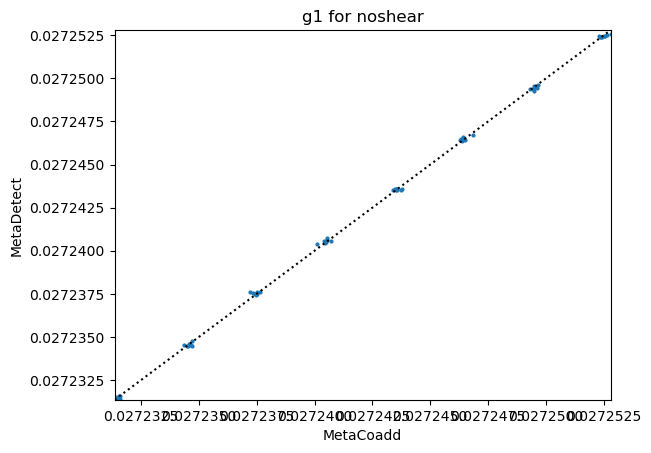

In [ ]:
vmin = np.min([final_cat["noshear"]["wmom_g1"], res["noshear"]["wmom_g"][:, 0]])
vmax = np.max([final_cat["noshear"]["wmom_g1"], res["noshear"]["wmom_g"][:, 0]])
plt.plot(final_cat["noshear"]["wmom_g1"], res["noshear"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axline((0., 0.), slope=1, color="k", linestyle=":")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")
plt.title("g1 for noshear")

Text(0.5, 1.0, 'g1 for noshear')

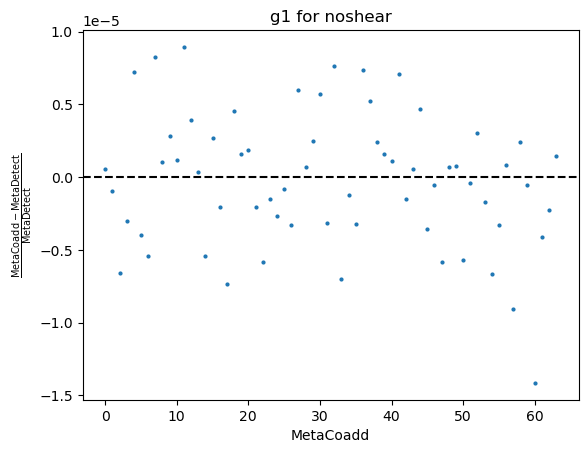

In [ ]:
plt.plot((final_cat["noshear"]["wmom_g1"]-res["noshear"]["wmom_g"][:, 0])/res["noshear"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for noshear")

Text(0.5, 1.0, 'g1 for 1p')

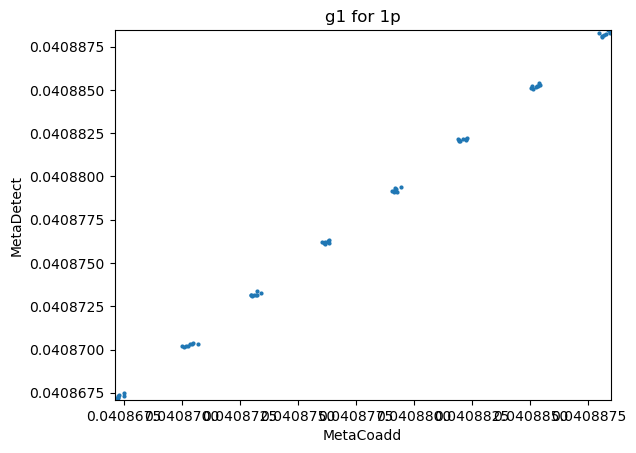

In [ ]:
vmin = np.min([final_cat["1p"]["wmom_g1"], res["1p"]["wmom_g"][:, 0]])
vmax = np.max([final_cat["1p"]["wmom_g1"], res["1p"]["wmom_g"][:, 0]])
plt.plot(final_cat["1p"]["wmom_g1"], res["1p"]["wmom_g"][:, 0], "o", markersize=2, label="noshear")
plt.axvline(0.01, color="k", linestyle="--")
plt.axhline(0.01, color="k", linestyle="--")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")
plt.title("g1 for 1p")

Text(0.5, 1.0, 'g1 for 1p')

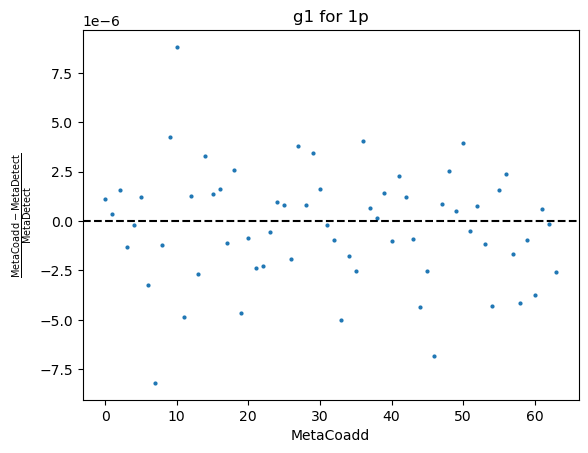

In [ ]:
plt.plot((final_cat["1p"]["wmom_g1"]-res["1p"]["wmom_g"][:, 0])/res["1p"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 1p")

Text(0, 0.5, 'MetaDetect')

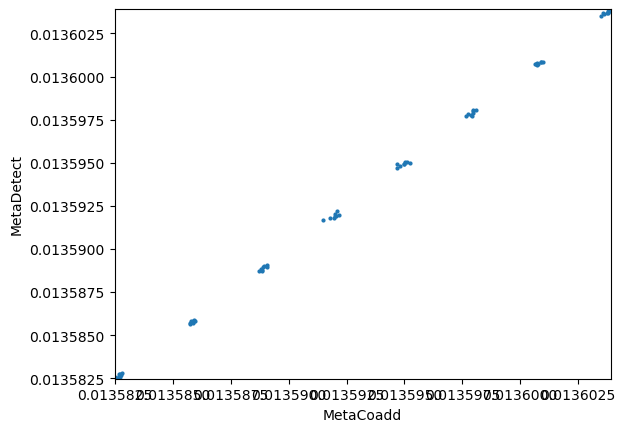

In [ ]:
vmin = np.min([final_cat["1m"]["wmom_g1"], res["1m"]["wmom_g"][:, 0]])
vmax = np.max([final_cat["1m"]["wmom_g1"], res["1m"]["wmom_g"][:, 0]])
plt.plot(final_cat["1m"]["wmom_g1"], res["1m"]["wmom_g"][:, 0], "o", markersize=2, label="noshear")
plt.axvline(-0.01, color="k", linestyle="--")
plt.axhline(-0.01, color="k", linestyle="--")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")

Text(0.5, 1.0, 'g1 for 1m')

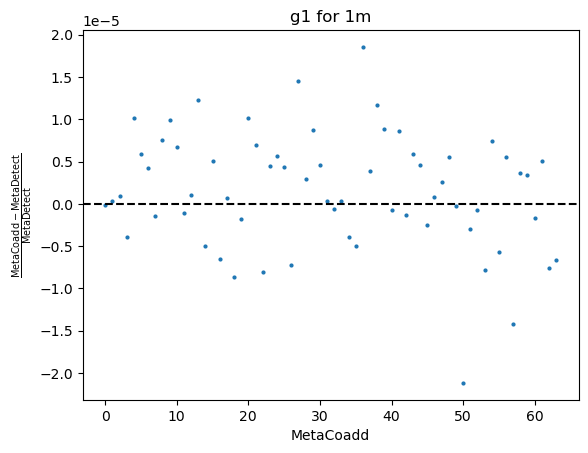

In [ ]:
plt.plot((final_cat["1m"]["wmom_g1"]-res["1m"]["wmom_g"][:, 0])/res["1m"]["wmom_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 1m")

Text(0.5, 1.0, 'g1 for 2m')

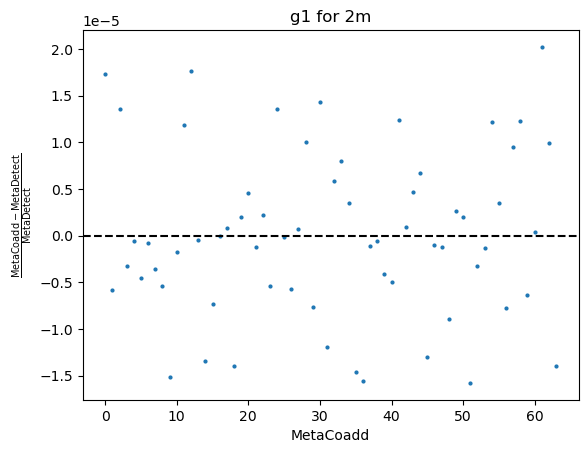

In [ ]:
plt.plot((final_cat["2m"]["wmom_g2"]-res["2m"]["wmom_g"][:, 1])/res["2m"]["wmom_g"][:, 1], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 2m")

Text(0, 0.5, 'MetaDetect')

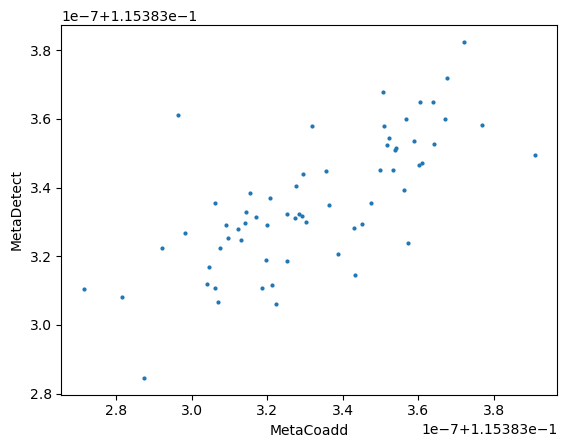

In [ ]:
plt.plot(final_cat["1m"]["wmom_T"], res["1m"]["wmom_T"], "o", markersize=2, label="noshear")
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")

Text(0.5, 1.0, 'T for noshear')

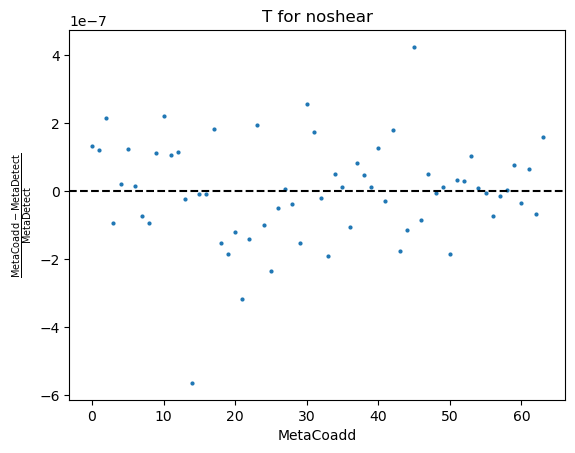

In [ ]:
plt.plot((final_cat["noshear"]["wmom_T"]-res["noshear"]["wmom_T"])/res["noshear"]["wmom_T"], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("MetaCoadd")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("T for noshear")

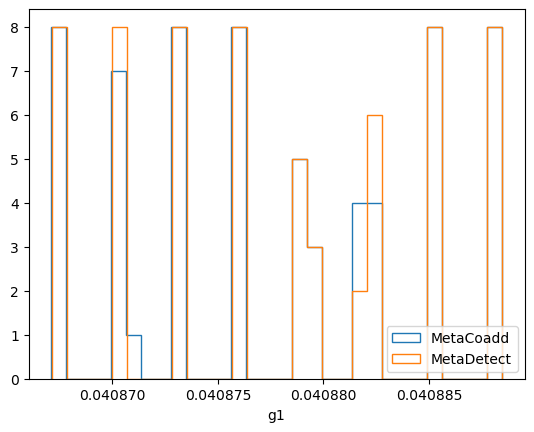

In [ ]:
key = "1p"
good_mc = (final_cat[key]["wmom_flags"] == 0) & (final_cat[key]["wmom_s2n"] > 10)
good_md = (res[key]["wmom_flags"] == 0) & (res[key]["wmom_s2n"] > 10)
plt.hist(final_cat[key]["wmom_g1"][good_mc], 30, histtype="step", label="MetaCoadd")
plt.hist(res[key]["wmom_g"][good_md, 0], 30, histtype="step", label="MetaDetect")
plt.xlabel("g1")
plt.legend()

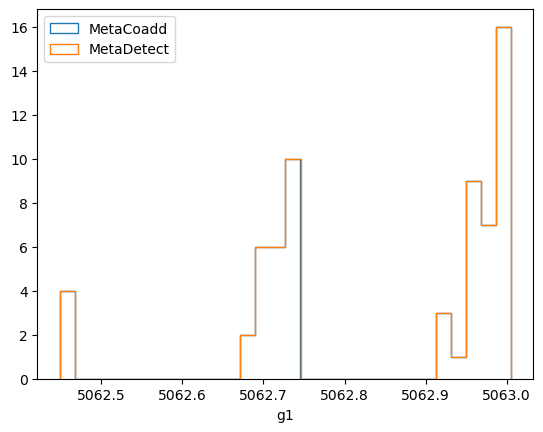

In [ ]:
key = "1p"
good_mc = (final_cat[key]["wmom_flags"] == 0) & (final_cat[key]["wmom_s2n"] > 10)
good_md = (res[key]["wmom_flags"] == 0) & (res[key]["wmom_s2n"] > 10)
plt.hist(final_cat[key]["wmom_flux_0"][good_mc], 30, histtype="step", label="MetaCoadd")
plt.hist(res[key]["wmom_band_flux"][good_md, 0], 30, histtype="step", label="MetaDetect")
plt.xlabel("g1")
plt.legend()

In [ ]:
final_cat[key]["wmom_g1"]

array([0.04086752, 0.04087036, 0.04087322, 0.0408821 , 0.04087634,
       0.04087944, 0.04088509, 0.04088798, 0.04087915, 0.04086751,
       0.04087067, 0.04087296, 0.04087628, 0.04088192, 0.0408854 ,
       0.04088843, 0.04086726, 0.04087017, 0.04087338, 0.04087602,
       0.04087917, 0.04088196, 0.04088502, 0.04088807, 0.04086717,
       0.04087025, 0.04087309, 0.04087633, 0.04087914, 0.04088223,
       0.04088512, 0.04088819, 0.0408671 , 0.04086999, 0.04087301,
       0.04087614, 0.04087928, 0.04088227, 0.04088808, 0.04088525,
       0.04086725, 0.04087617, 0.04088827, 0.04087011, 0.04087297,
       0.04087904, 0.0408819 , 0.04088527, 0.04087041, 0.0408732 ,
       0.04088845, 0.04086726, 0.04087628, 0.04087921, 0.04088191,
       0.04088532, 0.04087049, 0.04086728, 0.04087324, 0.04087611,
       0.04087919, 0.04088222, 0.04088537, 0.04088835])

In [ ]:
res[key]["wmom_g"][:, 0]

array([0.04086748, 0.04087034, 0.04087315, 0.04088215, 0.04087635,
       0.04087939, 0.04088522, 0.04088831, 0.0408792 , 0.04086733,
       0.04087031, 0.04087316, 0.04087623, 0.04088203, 0.04088527,
       0.04088838, 0.04086719, 0.04087021, 0.04087328, 0.04087622,
       0.0408792 , 0.04088206, 0.04088511, 0.0408881 , 0.04086713,
       0.04087021, 0.04087317, 0.04087617, 0.0408791 , 0.04088209,
       0.04088505, 0.0408882 , 0.04086714, 0.0408702 , 0.04087308,
       0.04087624, 0.04087911, 0.04088224, 0.04088807, 0.04088519,
       0.04086729, 0.04087608, 0.04088822, 0.04087014, 0.04087315,
       0.04087915, 0.04088218, 0.04088523, 0.04087031, 0.04087318,
       0.04088829, 0.04086728, 0.04087625, 0.04087925, 0.04088208,
       0.04088526, 0.04087039, 0.04086735, 0.0408734 , 0.04087615,
       0.04087934, 0.04088219, 0.04088538, 0.04088846])

In [ ]:
res["noshear"]["wmom_T"]

array([0.11541209, 0.11541209, 0.11541209, 0.11541209, 0.11541209,
       0.1154121 , 0.1154121 , 0.11541209, 0.11541209, 0.1154121 ,
       0.11541208, 0.11541209, 0.1154121 , 0.1154121 , 0.1154121 ,
       0.11541209, 0.11541211, 0.1154121 , 0.11541211, 0.1154121 ,
       0.11541208, 0.11541208, 0.11541209, 0.1154121 , 0.11541209,
       0.11541209, 0.11541207, 0.1154121 , 0.11541209, 0.11541209,
       0.11541209, 0.11541208, 0.11541208, 0.11541211, 0.11541207,
       0.11541208, 0.11541209, 0.11541208, 0.11541208, 0.1154121 ,
       0.11541209, 0.11541208, 0.1154121 , 0.11541208, 0.11541209,
       0.1154121 , 0.11541209, 0.11541208, 0.11541208, 0.11541209,
       0.11541208, 0.1154121 , 0.11541207, 0.11541209, 0.11541208,
       0.1154121 , 0.11541211, 0.11541211, 0.11541208, 0.11541209,
       0.11541208, 0.11541208, 0.11541209, 0.11541207])

In [ ]:
final_cat["noshear"]["wmom_T"]

array([0.11541211, 0.11541211, 0.11541211, 0.11541208, 0.11541209,
       0.11541211, 0.1154121 , 0.11541208, 0.11541208, 0.11541211,
       0.11541211, 0.1154121 , 0.11541211, 0.1154121 , 0.11541203,
       0.11541209, 0.11541211, 0.11541212, 0.1154121 , 0.11541208,
       0.11541206, 0.11541205, 0.11541207, 0.11541212, 0.11541208,
       0.11541206, 0.11541206, 0.1154121 , 0.11541209, 0.11541207,
       0.11541212, 0.1154121 , 0.11541207, 0.11541209, 0.11541208,
       0.11541208, 0.11541208, 0.11541209, 0.11541209, 0.1154121 ,
       0.1154121 , 0.11541208, 0.11541212, 0.11541206, 0.11541207,
       0.11541215, 0.11541208, 0.11541208, 0.11541208, 0.11541209,
       0.11541206, 0.1154121 , 0.11541207, 0.1154121 , 0.11541208,
       0.1154121 , 0.1154121 , 0.11541211, 0.11541208, 0.1154121 ,
       0.11541208, 0.11541209, 0.11541208, 0.11541209])